# Recipe Dataset - Exploratory Data Analysis

> **Objective:** Summarize the recipe dataset, visualize ingredient patterns, analyse recipe complexity, and perform bivariate comparisons.

---

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import os

# --- PATHS (edit here if your folder names differ) ---
HOME_DIR = '/content/drive/Shareddrives/Computer Vision Final Project'
DATA_DIR = os.path.join(HOME_DIR, 'Data', 'recipe_dataset', 'data')
NOTEBOOK_DIR = os.path.join(HOME_DIR, 'EDA')
OUT_DIR = os.path.join(NOTEBOOK_DIR, 'output_plots')

os.makedirs(OUT_DIR, exist_ok=True)
os.chdir(NOTEBOOK_DIR)

# Verify data exists
data_file = os.path.join(DATA_DIR, 'recipes.parquet')
if os.path.exists(data_file):
    print(f'Data found: {data_file}')
else:
    # Fallback: try CSV
    data_file = os.path.join(DATA_DIR, 'recipes.csv')
    if os.path.exists(data_file):
        print(f'Data found (CSV): {data_file}')
    else:
        print(f'WARNING: Data NOT found in {DATA_DIR}')
        print('Available files:', os.listdir(DATA_DIR) if os.path.isdir(DATA_DIR) else 'DIR MISSING')


Data found: /content/drive/Shareddrives/Computer Vision Final Project/Data/recipe_dataset/data/recipes.parquet


In [3]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import ast, re, warnings
from collections import Counter
from itertools import combinations

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 140,
    'savefig.dpi': 180,
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Helvetica', 'Arial'],
    'axes.titlesize': 14,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

PALETTE = sns.color_palette('viridis', 25)

print('Libraries loaded & plot style configured.')


Libraries loaded & plot style configured.


In [4]:
# Load dataset (prefer parquet, fall back to csv)
parquet_path = os.path.join(DATA_DIR, 'recipes.parquet')
csv_path = os.path.join(DATA_DIR, 'recipes.csv')

if os.path.exists(parquet_path):
    df = pd.read_parquet(parquet_path)
    print(f'Loaded from parquet: {parquet_path}')
elif os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    print(f'Loaded from CSV: {csv_path}')
else:
    raise FileNotFoundError(f'No data file found in {DATA_DIR}')

print(f'Loaded {len(df):,} recipes  |  Columns: {list(df.columns)}')
df.head(3)


Loaded from parquet: /content/drive/Shareddrives/Computer Vision Final Project/Data/recipe_dataset/data/recipes.parquet
Loaded 13,509 recipes  |  Columns: ['dish_id', 'dish_name', 'recipe', 'photo_path', 'source']


,dish_id,dish_name,recipe,photo_path,source
0,KG-000001,Miso-Butter Roast Chicken With Acorn Squash Pa...,"Ingredients:\n['1 (3½–4-lb.) whole chicken', '...",photos/KG-000001.jpg,kaggle_epicurious
1,KG-000002,Crispy Salt and Pepper Potatoes,"Ingredients:\n['2 large egg whites', '1 pound ...",photos/KG-000002.jpg,kaggle_epicurious
2,KG-000003,Thanksgiving Mac and Cheese,"Ingredients:\n['1 cup evaporated milk', '1 cup...",photos/KG-000003.jpg,kaggle_epicurious


In [5]:
_PORT_UNITS = {'cup','cups','tbsp','tsp','tablespoon','tablespoons','teaspoon','teaspoons','oz','ounce','ounces','lb','lbs','pound','pounds','quart','quarts','gallon','gallons','pint','pints','ml','g','kg','liter','liters','inch','inches','clove','cloves','can','cans','stick','sticks','package','packages','pinch','piece','pieces','slice','slices','sprig','sprigs','bunch','bunches','head','heads','small','medium','large','whole','half'}
_PORT_VERBS = {'chopped','diced','minced','sliced','grated','crushed','peeled','melted','softened','divided','optional','fresh','freshly','finely','coarsely','roughly','thinly','plus','about','to','taste','for','garnish','more','room','temperature','extra','additional'}
_PORT_NUMRE = re.compile(r'^[\d\u00bc\u00bd\u00be\u2153\u2154\u215b\u215c\u215d\u215e/.\-\u2013\u2014]+$')

def extract_instructions(t):
    if not isinstance(t, str):
        return ''
    parts = t.split('Instructions:', 1)
    return parts[1].strip() if len(parts) > 1 else ''

def extract_ingredient_portions(t):
    if not isinstance(t, str):
        return []
    block = t.split('Instructions:')[0] if 'Instructions:' in t else t
    block = block.replace('Ingredients:', '').strip()
    if block.startswith('['):
        items = ast.literal_eval(block)
    else:
        items = [ln.lstrip('- ').strip() for ln in block.splitlines() if ln.strip().startswith('-')]
    return [i.strip() for i in items if isinstance(i, str) and i.strip()]

def clean_ingredient_name(raw):
    raw = re.sub(r'\(.*?\)', '', raw)
    raw = re.sub(r'[,;].*', '', raw)
    tokens = [tok.strip('\'"') for tok in raw.lower().split()]
    tokens = [tok for tok in tokens if not _PORT_NUMRE.match(tok)]
    tokens = [tok for tok in tokens if tok not in _PORT_UNITS and tok not in _PORT_VERBS]
    name = ' '.join(tokens).strip(' -\u2013\u2014\u2022')
    return name if name else raw.lower().strip()

df['instructions'] = df['recipe'].apply(extract_instructions)
df['ingredient_portions'] = df['recipe'].apply(extract_ingredient_portions)
df['ingredients'] = df['ingredient_portions'].apply(lambda items: [clean_ingredient_name(i) for i in items])
df['n_ingredients'] = df['ingredients'].apply(len)

print('Added columns -> instructions, ingredients, n_ingredients, ingredient_portions')
print('Example ingredient_portions[0]:', df['ingredient_portions'].iloc[0][:3])
print('Example ingredients[0]:', df['ingredients'].iloc[0][:3])
df[['instructions', 'ingredients', 'n_ingredients', 'ingredient_portions']].head(3)

Added columns -> instructions, ingredients, n_ingredients, ingredient_portions
Example ingredient_portions[0]: ['1 (3½–4-lb.) whole chicken', '2¾ tsp. kosher salt, divided, plus more', '2 small acorn squash (about 3 lb. total)']
Example ingredients[0]: ['chicken', 'tsp. kosher salt', 'acorn squash']


,instructions,ingredients,n_ingredients,ingredient_portions
0,"Pat chicken dry with paper towels, season all ...","[chicken, tsp. kosher salt, acorn squash, tbsp...",21,"[1 (3½–4-lb.) whole chicken, 2¾ tsp. kosher sa..."
1,Preheat oven to 400°F and line a rimmed baking...,"[egg whites, new potatoes, kosher salt, ground...",7,"[2 large egg whites, 1 pound new potatoes (abo..."
2,Place a rack in middle of oven; preheat to 400...,"[evaporated milk, milk, tsp. garlic powder, ts...",10,"[1 cup evaporated milk, 1 cup whole milk, 1 ts..."


## 1 - Data Preparation: Ingredient Parsing

Each recipe stores its ingredient list inside the `recipe` column as either a Python list literal (Kaggle/Epicurious) or a dash-separated list (Spoonacular). We parse both formats, then normalise ingredient names to their core tokens (remove quantities, units, and prep verbs).


In [6]:
_UNITS = {
    'cup','cups','tbsp','tsp','tablespoon','tablespoons','teaspoon','teaspoons',
    'oz','ounce','ounces','lb','lbs','pound','pounds','quart','quarts','gallon',
    'gallons','pint','pints','ml','g','kg','liter','liters','inch','inches',
    'clove','cloves','can','cans','stick','sticks','package','packages','pinch',
    'piece','pieces','slice','slices','sprig','sprigs','bunch','bunches','head','heads',
    'small','medium','large','whole','half'
}
_PREP_VERBS = {
    'chopped','diced','minced','sliced','grated','crushed','peeled','melted',
    'softened','divided','optional','fresh','freshly','finely','coarsely',
    'roughly','thinly','plus','about','to','taste','for','garnish','more',
    'room','temperature','extra','additional'
}
_NUM_RE = re.compile(r'^[\d\u00bc\u00bd\u00be\u2153\u2154\u215b\u215c\u215d\u215e/.\-\u2013\u2014]+$')

def _clean_ingredient(raw: str) -> str:
    raw = re.sub(r'\(.*?\)', '', raw)
    raw = re.sub(r'[,;].*', '', raw)
    tokens = raw.lower().split()
    tokens = [t.strip('\'\"') for t in tokens]
    tokens = [t for t in tokens if not _NUM_RE.match(t)]
    tokens = [t for t in tokens if t not in _UNITS and t not in _PREP_VERBS]
    name = ' '.join(tokens).strip(' -\u2013\u2014\u2022')
    return name if name else raw.lower().strip()

def parse_ingredients(recipe_text: str) -> list:
    if pd.isna(recipe_text):
        return []
    ingr_block = recipe_text.split('Instructions:')[0].replace('Ingredients:', '').strip() if 'Instructions:' in recipe_text else recipe_text.replace('Ingredients:', '').strip()
    raw_items = []
    if ingr_block.startswith('['):
        try:
            raw_items = ast.literal_eval(ingr_block)
        except Exception:
            raw_items = [s.strip(" '\"") for s in ingr_block.strip('[]').split("',")]
    else:
        raw_items = [line.lstrip('- ').strip() for line in ingr_block.splitlines() if line.strip().startswith('-')]
    return [_clean_ingredient(i) for i in raw_items if i.strip()]

df['ingredients'] = df['recipe'].apply(parse_ingredients)
df['n_ingredients'] = df['ingredients'].apply(len)

print(f'Parsed ingredients for {len(df):,} recipes.')
print(f'Ingredient counts -- min: {df["n_ingredients"].min()}, '
      f'max: {df["n_ingredients"].max()}, '
      f'mean: {df["n_ingredients"].mean():.1f}, '
      f'median: {df["n_ingredients"].median():.0f}')


Parsed ingredients for 13,509 recipes.
Ingredient counts -- min: 0, max: 51, mean: 10.6, median: 10


### Cuisine Classification (Keyword Heuristic)

The dataset has no explicit cuisine column, so we assign a cuisine label by scanning each recipe's dish name and ingredient list for cuisine-specific keywords (e.g. *soy sauce -> Asian*, *tortilla -> Mexican*).


In [7]:
_CUISINE_RULES = [
    ('Asian',    ['soy sauce','sesame','ginger','tofu','rice vinegar','hoisin',
                  'miso','teriyaki','wok','stir-fry','noodle','dumpling',
                  'dim sum','ramen','pho','thai','szechuan','korean','kimchi',
                  'fish sauce','lemongrass','coconut milk curry']),
    ('Indian',   ['curry','turmeric','cumin','garam masala','naan','paneer',
                  'tikka','masala','biryani','dal','chutney','cardamom',
                  'coriander seed','tandoori']),
    ('Mexican',  ['tortilla','taco','burrito','jalapeno','chipotle','enchilada',
                  'salsa','queso','guacamole','cilantro lime','chile verde',
                  'tostada','quesadilla','mole','tamale']),
    ('Italian',  ['pasta','risotto','prosciutto','parmigiano','parmesan',
                  'mozzarella','marinara','lasagna','gnocchi','focaccia',
                  'polenta','pesto','bruschetta','tiramisu','bolognese',
                  'carbonara','arrabbiata','ciabatta']),
    ('Mediterranean', ['hummus','tahini','feta','pita','couscous',
                       'harissa','zaatar','olive oil lemon','sumac',
                       'lamb','eggplant yogurt','falafel','tabbouleh',
                       'pomegranate','flatbread']),
    ('American', ['burger','mac and cheese','cornbread','bbq','barbecue',
                  'bacon','coleslaw','brisket','buffalo','ranch',
                  'fried chicken','meatloaf','pot roast','brownie',
                  'pancake','waffle']),
    ('French',   ['croissant','baguette','gratin','souffle','roux',
                  'bearnaise','bechamel','creme','tarte','confit',
                  'ratatouille','bouillabaisse','brioche','quiche']),
]

def classify_cuisine(row):
    text = (row['dish_name'] + ' ' + ' '.join(row['ingredients'])).lower()
    for cuisine, keywords in _CUISINE_RULES:
        if any(kw in text for kw in keywords):
            return cuisine
    return 'Other'

df['cuisine'] = df.apply(classify_cuisine, axis=1)
print('Cuisine distribution:')
print(df['cuisine'].value_counts().to_string())


Cuisine distribution:
cuisine
Other            6976
Asian            2272
Italian          1331
Indian           1035
American          637
Mediterranean     583
Mexican           412
French            263


### Recipe Rating Proxy

No explicit rating column exists. As a proxy we assign a **1-5 star rating** based on the richness of the recipe -- weighted by ingredient diversity, instruction length, and number of technique verbs (e.g. *braise, saute, roast*).


In [8]:
_TECHNIQUE_WORDS = {
    'braise','roast','saute','caramelize','deglaze','flambe',
    'blanch','poach','sear','simmer','baste','julienne','fold','temper',
    'sous vide','smoke','cure','ferment','confit','emulsify','reduce',
    'bloom','rest','marinate'
}

def _rating_proxy(row):
    n_ingr = row['n_ingredients']
    recipe_text = str(row['recipe']).lower()
    instr = recipe_text.split('instructions:')[-1] if 'instructions:' in recipe_text else ''
    n_words = len(instr.split())
    n_tech = sum(1 for w in _TECHNIQUE_WORDS if w in instr)
    raw = 0.3 * min(n_ingr, 25) + 0.005 * min(n_words, 500) + 0.8 * min(n_tech, 8)
    return raw

df['_raw_rating'] = df.apply(_rating_proxy, axis=1)
df['rating'] = pd.qcut(df['_raw_rating'], q=5, labels=[1,2,3,4,5]).astype(int)
df.drop(columns=['_raw_rating'], inplace=True)

print('Rating distribution:')
print(df['rating'].value_counts().sort_index().to_string())


Rating distribution:
rating
1    2702
2    2704
3    2702
4    2701
5    2700


---
## 2 - Dataset Summary


In [9]:
print('=' * 55)
print('       RECIPE DATASET SUMMARY')
print('=' * 55)
print(f'  Total recipes          : {len(df):>8,}')
print(f'  Unique dish names      : {df["dish_name"].nunique():>8,}')
print(f'  Sources                : {chr(44).join(" " + s for s in df["source"].unique())}')
print(f'  Avg ingredients/recipe : {df["n_ingredients"].mean():>8.1f}')
print(f'  Median ingredients     : {df["n_ingredients"].median():>8.0f}')
print(f'  Std dev                : {df["n_ingredients"].std():>8.1f}')
print(f'  Min / Max ingredients  : {df["n_ingredients"].min()} / {df["n_ingredients"].max()}')
print('=' * 55)


       RECIPE DATASET SUMMARY
  Total recipes          :   13,509
  Unique dish names      :   13,319
  Sources                :  kaggle_epicurious, spoonacular
  Avg ingredients/recipe :     10.6
  Median ingredients     :       10
  Std dev                :      4.8
  Min / Max ingredients  : 0 / 51


In [21]:
import numpy as np
import os
from itertools import combinations
import time
import pandas as pd # Import pandas for CSV saving

# Define paths for saving
matrix_npy_save_path = os.path.join(DATA_DIR, 'ingredient_similarity_matrix.npy')
matrix_csv_save_path = os.path.join(DATA_DIR, 'ingredient_similarity_matrix.csv')

# 1. Check if similarity matrix already exists (NPY)
if os.path.exists(matrix_npy_save_path):
    print(f"Loading existing ingredient similarity matrix from: {matrix_npy_save_path}")
    similarity_matrix = np.load(matrix_npy_save_path)
    num_dishes = len(df) # Ensure num_dishes is defined if loaded
    print("Similarity matrix loaded.")
else:
    # 1. Extract ingredient sets for each recipe
    ingredient_sets = df['ingredients'].apply(set).tolist()

    # 2. Initialize a similarity matrix
    num_dishes = len(df)
    # Use int8 as max ingredients is 51, fitting within -128 to 127
    similarity_matrix = np.zeros((num_dishes, num_dishes), dtype=np.int8)

    print(f"Calculating ingredient similarity matrix for {num_dishes} dishes...")
    start_time = time.time()

    # 3. Populate the matrix
    # For efficiency, only compute upper triangle and then mirror
    for i in range(num_dishes):
        # Self-similarity (number of ingredients in the dish itself)
        similarity_matrix[i, i] = len(ingredient_sets[i])
        for j in range(i + 1, num_dishes):
            shared_count = len(ingredient_sets[i].intersection(ingredient_sets[j]))
            similarity_matrix[i, j] = shared_count
            similarity_matrix[j, i] = shared_count # Mirror for symmetry

        if (i + 1) % 1000 == 0 or i == num_dishes - 1:
            elapsed_time = time.time() - start_time
            print(f"  Processed {i + 1}/{num_dishes} dishes ({elapsed_time:.1f} seconds)")

    print("Similarity matrix calculation complete.")
    end_time = time.time()
    print(f"Total time for matrix calculation: {end_time - start_time:.1f} seconds.")

    # 4. Save the matrix as NPY if it was just calculated
    np.save(matrix_npy_save_path, similarity_matrix)
    print(f"Ingredient similarity matrix saved to: {matrix_npy_save_path}")

# 5. Save the matrix as CSV with dish IDs as row/column names
print(f"Saving ingredient similarity matrix to CSV: {matrix_csv_save_path}")
# Ensure dish_ids are available from the DataFrame for row/column names
dish_ids = df['dish_id'].tolist()
similarity_df = pd.DataFrame(similarity_matrix, index=dish_ids, columns=dish_ids)
similarity_df.to_csv(matrix_csv_save_path)
print("Ingredient similarity matrix saved to CSV.")

# 6. Calculate mean and median number of shared ingredients between any two dishes
# Exclude diagonal elements (self-similarity)
# Since the matrix is symmetric, the upper triangle (excluding diagonal) contains all unique pair similarities
upper_triangle_indices = np.triu_indices(num_dishes, k=1) # k=1 excludes diagonal
shared_ingredients_values = similarity_matrix[upper_triangle_indices]

mean_shared_ingredients = np.mean(shared_ingredients_values)
median_shared_ingredients = np.median(shared_ingredients_values)

print(f"\nMean number of shared ingredients between any two dishes: {mean_shared_ingredients:.2f}")
print(f"Median number of shared ingredients between any two dishes: {median_shared_ingredients:.0f}")


Loading existing ingredient similarity matrix from: /content/drive/Shareddrives/Computer Vision Final Project/Data/recipe_dataset/data/ingredient_similarity_matrix.npy
Similarity matrix loaded.
Saving ingredient similarity matrix to CSV: /content/drive/Shareddrives/Computer Vision Final Project/Data/recipe_dataset/data/ingredient_similarity_matrix.csv
Ingredient similarity matrix saved to CSV.

Mean number of shared ingredients between any two dishes: 0.50
Median number of shared ingredients between any two dishes: 0


### Missing-Value Analysis

Rows with 0 parsed ingredients (effectively missing): 7 (0.05%)

    Column  Missing Count  Missing %
   dish_id              0        0.0
 dish_name              0        0.0
    recipe              0        0.0
photo_path              0        0.0
    source              0        0.0


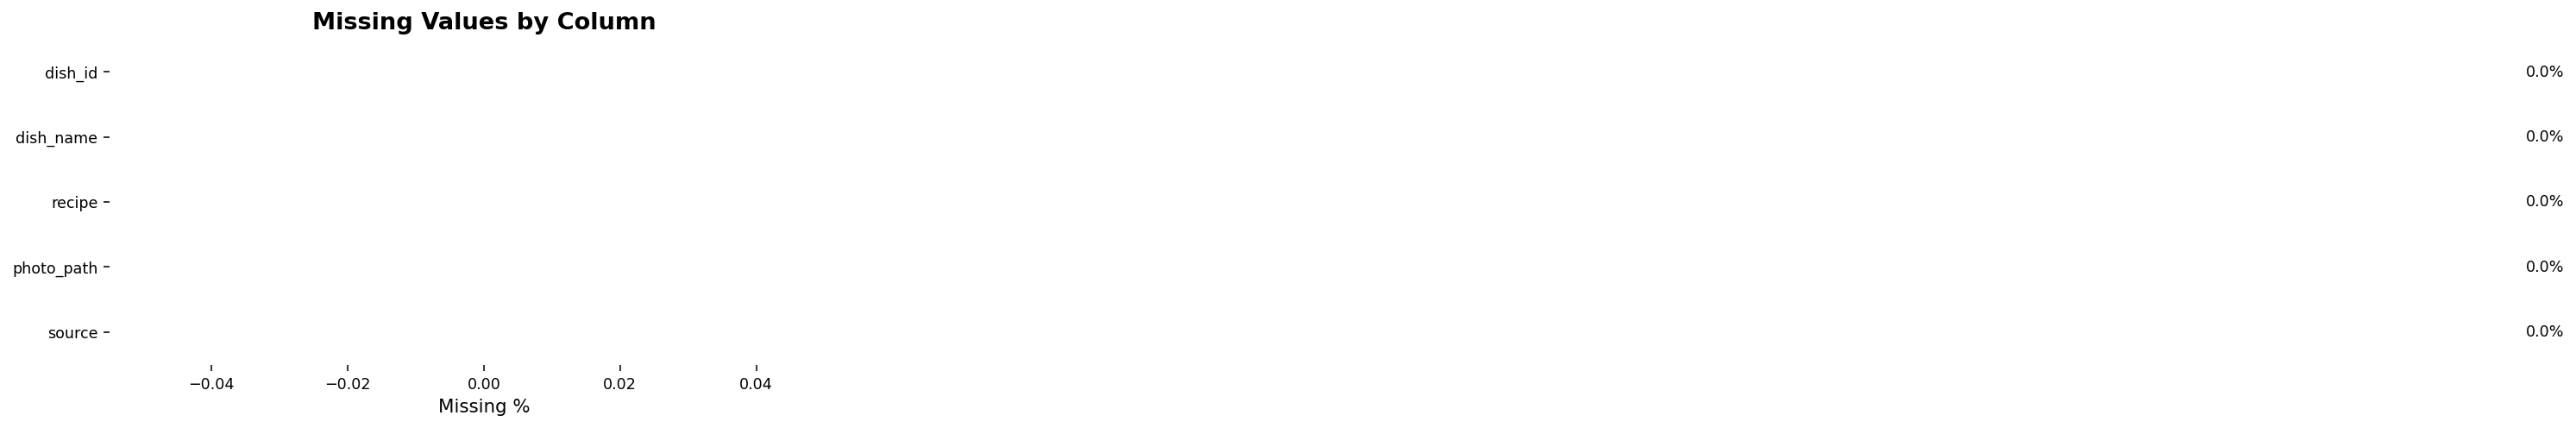

In [11]:
missing = df[['dish_id','dish_name','recipe','photo_path','source']].isnull().sum().reset_index()
missing.columns = ['Column', 'Missing Count']
missing['Missing %'] = (missing['Missing Count'] / len(df) * 100).round(2)
empty_ingr = (df['n_ingredients'] == 0).sum()
print(f'Rows with 0 parsed ingredients (effectively missing): {empty_ingr} ({empty_ingr/len(df)*100:.2f}%)\n')
print(missing.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 3.5))
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in missing['Missing Count']]
bars = ax.barh(missing['Column'], missing['Missing %'], color=colors, edgecolor='white', height=0.55)
ax.set_xlabel('Missing %')
ax.set_title('Missing Values by Column', weight='bold')
ax.invert_yaxis()
for bar, pct in zip(bars, missing['Missing %']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%', va='center', fontsize=9)
sns.despine(left=True, bottom=True)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'missing_values.png'), bbox_inches='tight')
plt.show()


---
## 3 - Top-N Most Common Ingredients (Bar Chart)


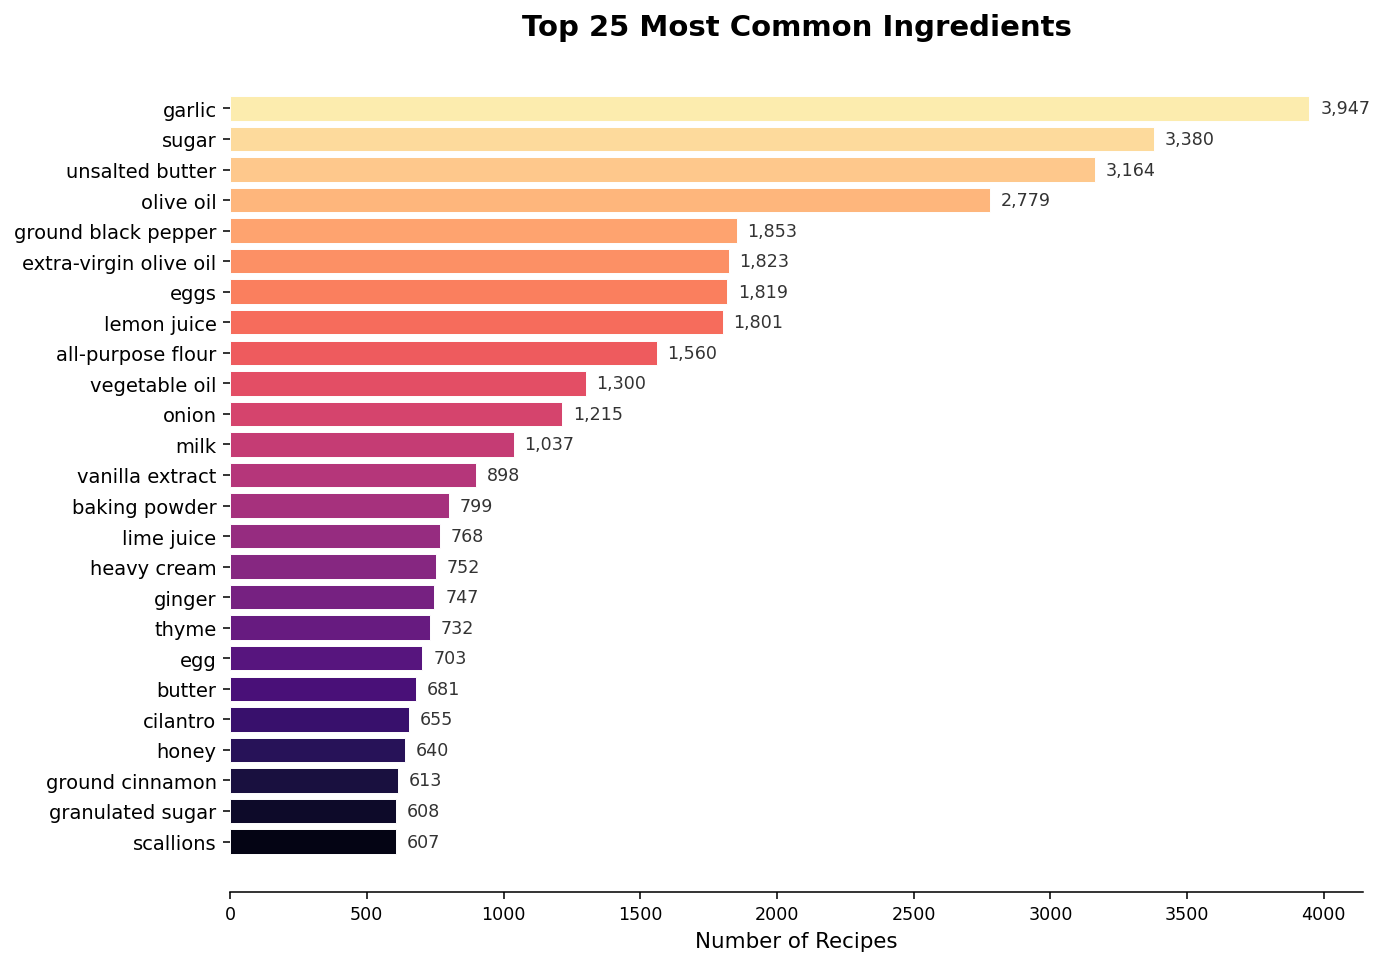


Unique ingredients (after cleaning): 25,337


In [12]:
all_ingredients = [ingr for lst in df['ingredients'] for ingr in lst]
ingr_counts = Counter(all_ingredients)

_STOPWORDS = {'', 'salt', 'pepper', 'water', 'kosher salt', 'salt and', 'and pepper',
              'freshly ground pepper', 'freshly ground black pepper',
              'kosher salt freshly ground pepper', 'black pepper'}
for sw in _STOPWORDS:
    ingr_counts.pop(sw, None)

TOP_N = 25
top_ingr = ingr_counts.most_common(TOP_N)
labels, counts = zip(*top_ingr)

fig, ax = plt.subplots(figsize=(10, 7))
palette = sns.color_palette('magma_r', TOP_N)
bars = ax.barh(range(TOP_N), counts, color=palette, edgecolor='white', linewidth=0.5)
ax.set_yticks(range(TOP_N))
ax.set_yticklabels(labels, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Number of Recipes', fontsize=11)
ax.set_title(f'Top {TOP_N} Most Common Ingredients', fontsize=15, weight='bold', pad=12)

for bar, cnt in zip(bars, counts):
    ax.text(bar.get_width() + max(counts)*0.01, bar.get_y() + bar.get_height()/2,
            f'{cnt:,}', va='center', fontsize=9, color='#333')

sns.despine(left=True)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'top_ingredients_bar.png'), bbox_inches='tight')
plt.show()

print(f'\nUnique ingredients (after cleaning): {len(ingr_counts):,}')


---
## 4 - Ingredient Co-Occurrence Heatmap

We build a co-occurrence matrix for the **top 15** ingredients and visualise it as a heatmap.


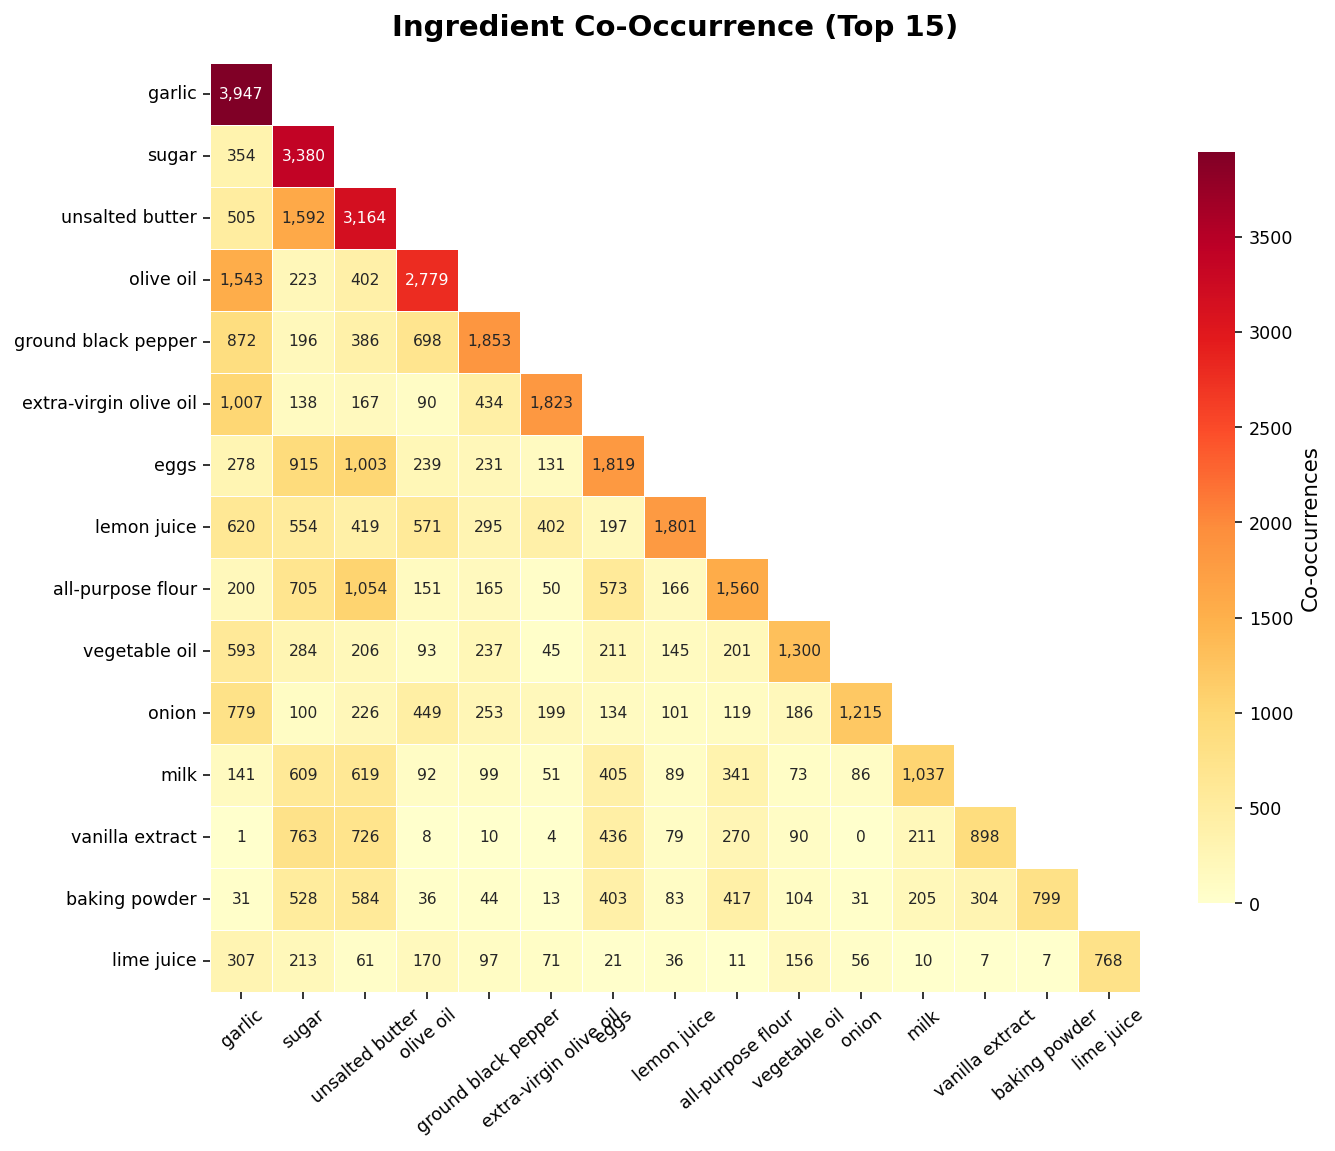

In [13]:
TOP_CO = 15
top_co_names = [name for name, _ in ingr_counts.most_common(TOP_CO)]

cooccur = pd.DataFrame(0, index=top_co_names, columns=top_co_names)
for ingr_list in df['ingredients']:
    present = [i for i in ingr_list if i in cooccur.index]
    for a, b in combinations(present, 2):
        cooccur.loc[a, b] += 1
        cooccur.loc[b, a] += 1

for name in top_co_names:
    cooccur.loc[name, name] = ingr_counts[name]

fig, ax = plt.subplots(figsize=(10, 8.5))
mask = np.zeros_like(cooccur, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True
sns.heatmap(cooccur, mask=mask, annot=True, fmt=',', cmap='YlOrRd',
            linewidths=0.5, linecolor='white', square=True,
            cbar_kws={'shrink': 0.75, 'label': 'Co-occurrences'},
            ax=ax, annot_kws={'fontsize': 8})
ax.set_title('Ingredient Co-Occurrence (Top 15)', fontsize=15, weight='bold', pad=14)
ax.tick_params(axis='x', rotation=40)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'ingredient_cooccurrence_heatmap.png'), bbox_inches='tight')
plt.show()


---
## 5 - Recipe Complexity Distribution (Violin + Box Plot)

We define **complexity** as the number of ingredients per recipe.


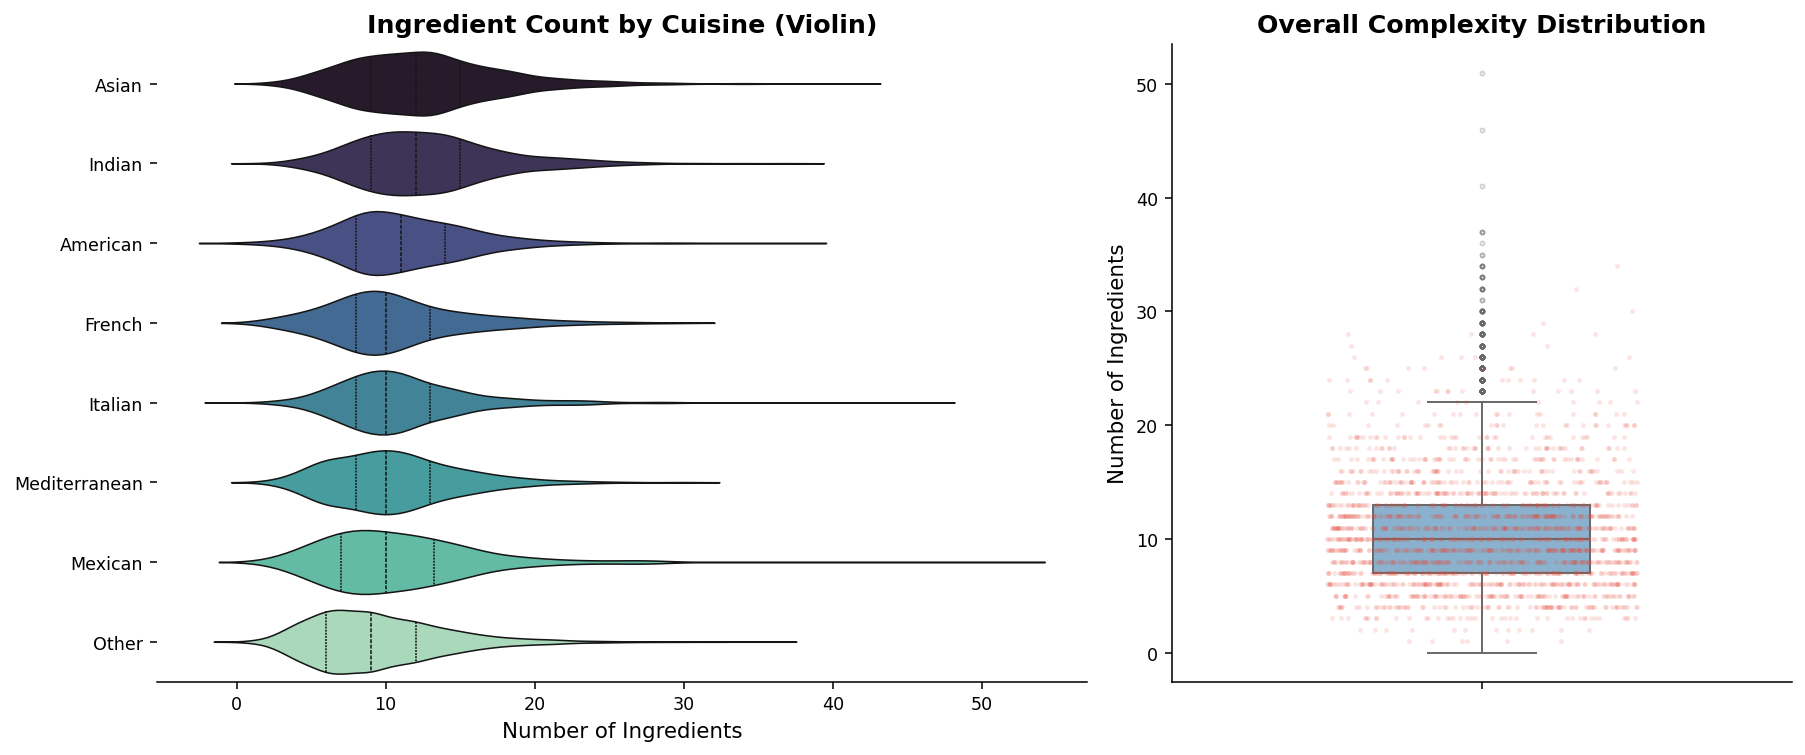

Mean: 10.6  |  Median: 10  |  Std: 4.8  |  IQR: 7-13


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), gridspec_kw={'width_ratios': [3, 2]})

# Violin plot by cuisine
order = df.groupby('cuisine')['n_ingredients'].median().sort_values(ascending=False).index.tolist()
valid = df.groupby('cuisine').filter(lambda g: len(g) >= 30)['cuisine'].unique()
order = [c for c in order if c in valid]

sns.violinplot(data=df[df['cuisine'].isin(order)], y='cuisine', x='n_ingredients',
               order=order, palette='mako', inner='quart', linewidth=0.8, ax=axes[0])
axes[0].set_title('Ingredient Count by Cuisine (Violin)', weight='bold', fontsize=13)
axes[0].set_xlabel('Number of Ingredients')
axes[0].set_ylabel('')
sns.despine(ax=axes[0], left=True)

# Overall box plot with strip
sns.boxplot(data=df, y='n_ingredients', color='#7fb3d8', width=0.35,
            flierprops=dict(marker='o', markersize=2, alpha=0.3), ax=axes[1])
sns.stripplot(data=df.sample(min(2000, len(df)), random_state=42),
              y='n_ingredients', color='#e74c3c', alpha=0.15, size=2.5, jitter=0.25, ax=axes[1])
axes[1].set_title('Overall Complexity Distribution', weight='bold', fontsize=13)
axes[1].set_ylabel('Number of Ingredients')
sns.despine(ax=axes[1])

plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'complexity_distribution.png'), bbox_inches='tight')
plt.show()

print(f'Mean: {df["n_ingredients"].mean():.1f}  |  Median: {df["n_ingredients"].median():.0f}  |  '
      f'Std: {df["n_ingredients"].std():.1f}  |  IQR: '
      f'{df["n_ingredients"].quantile(0.25):.0f}-{df["n_ingredients"].quantile(0.75):.0f}')


---
## 6 - Bivariate Analysis

### 6a -- Cuisine Type vs. Ingredient Frequency

For each cuisine we compute the most *distinctive* ingredients (those appearing at a much higher rate than the dataset average).


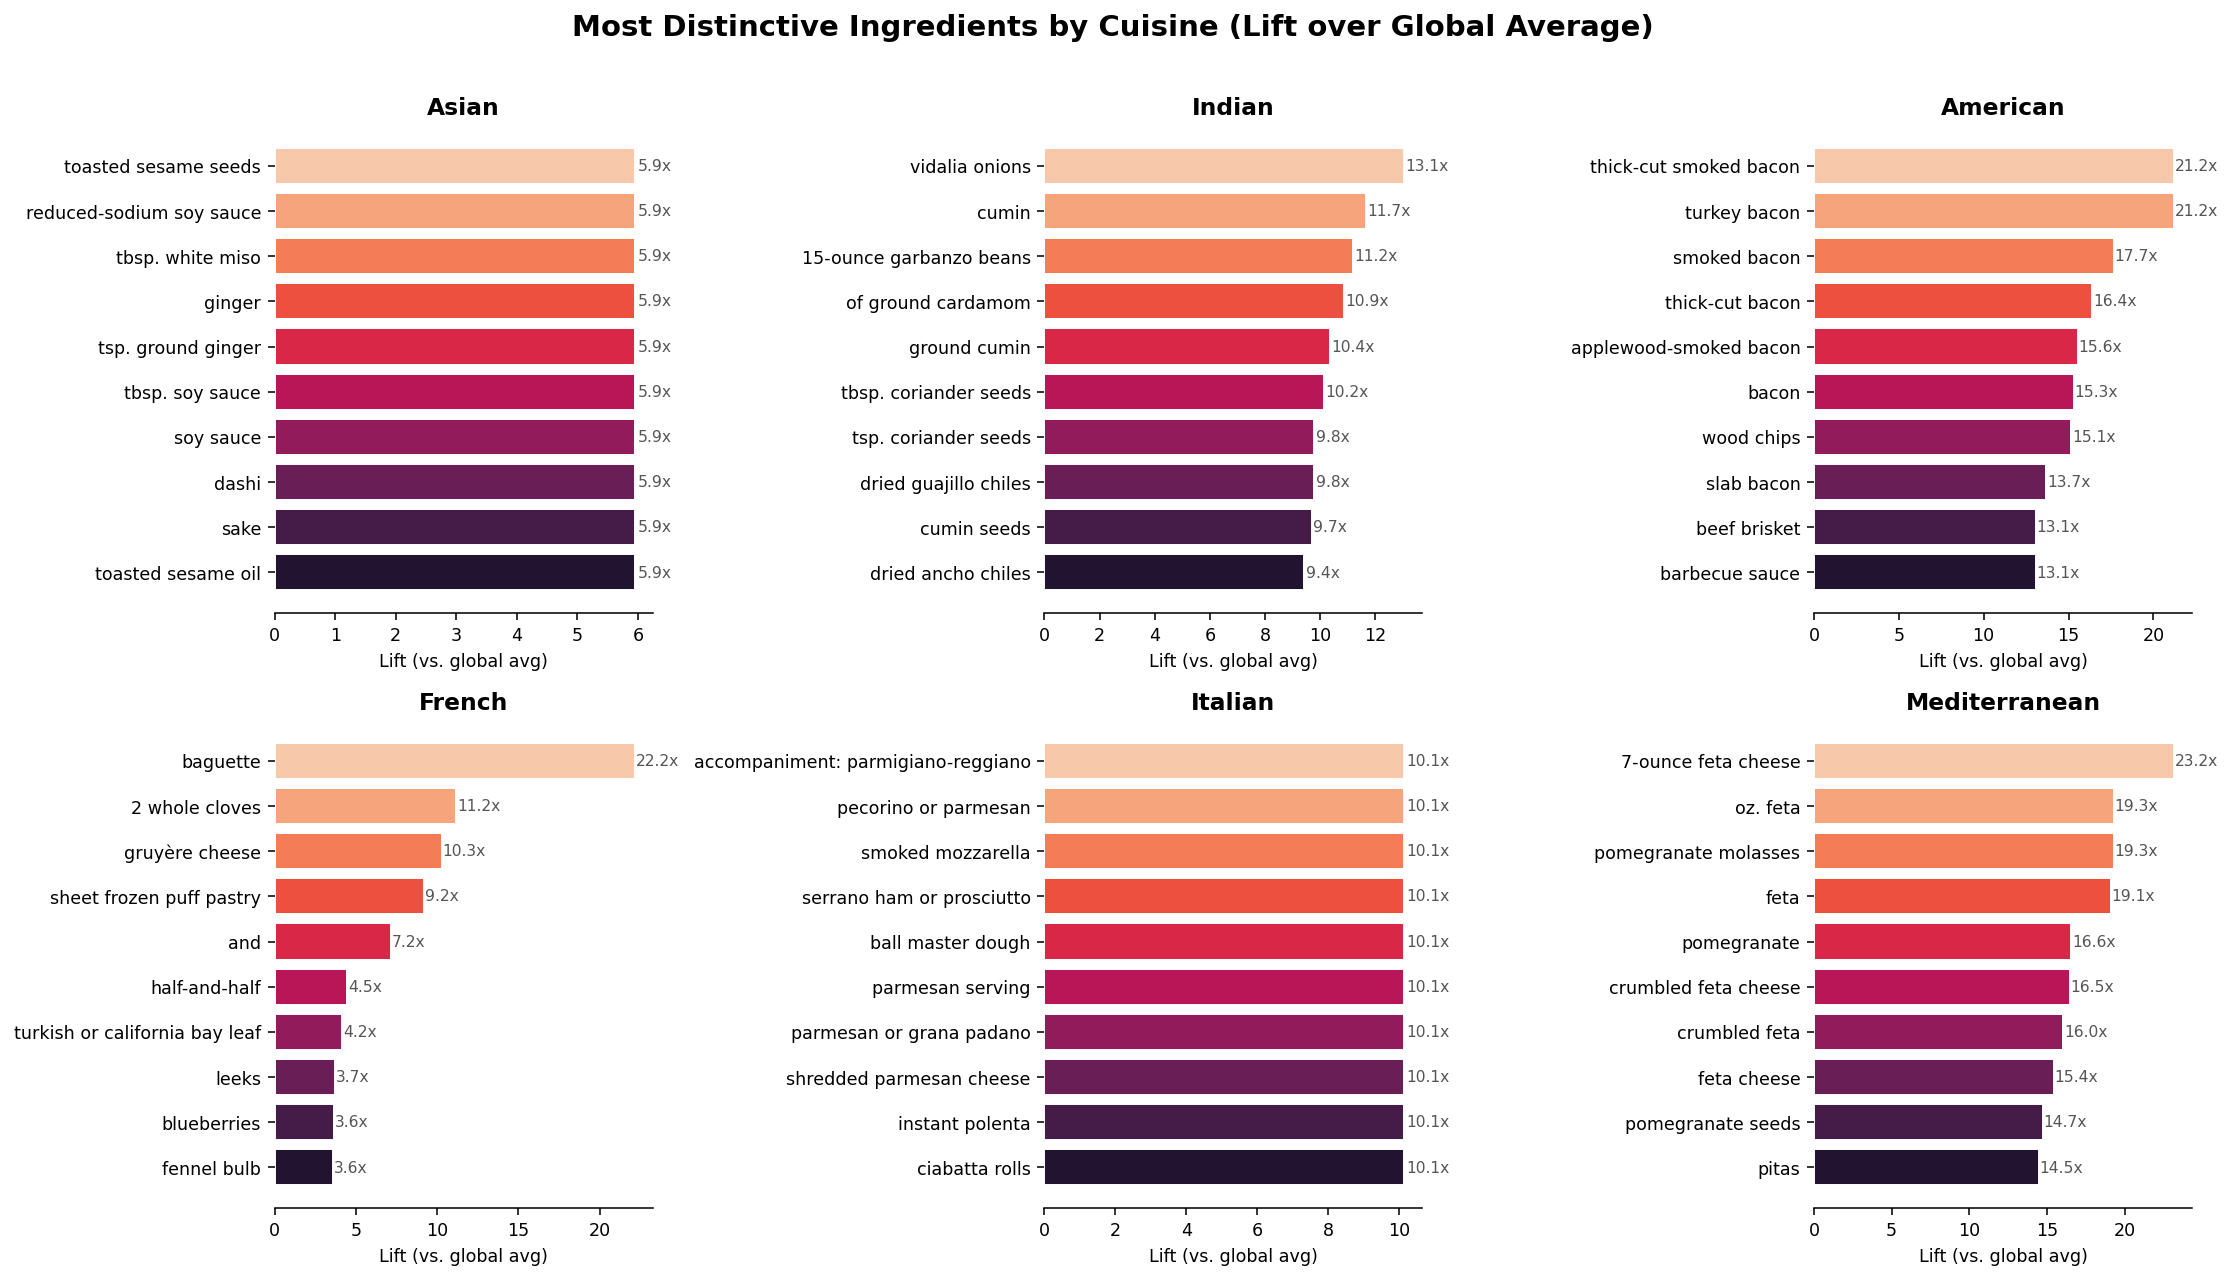

In [15]:
global_freq = Counter(all_ingredients)
n_total = len(df)

cuisines_of_interest = [c for c in order if c != 'Other'][:6]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

for idx, cuisine in enumerate(cuisines_of_interest):
    subset = df[df['cuisine'] == cuisine]
    local_counts = Counter(ingr for lst in subset['ingredients'] for ingr in lst)
    for sw in _STOPWORDS:
        local_counts.pop(sw, None)
    lifts = {}
    for ingr, cnt in local_counts.items():
        local_frac = cnt / len(subset)
        global_frac = global_freq.get(ingr, 1) / n_total
        lifts[ingr] = (local_frac / global_frac, cnt)
    top_lift = sorted(
        [(k, v[0], v[1]) for k, v in lifts.items() if v[1] >= 5],
        key=lambda x: x[1], reverse=True
    )[:10]
    names = [t[0] for t in top_lift]
    lift_vals = [t[1] for t in top_lift]

    ax = axes[idx]
    bars = ax.barh(range(len(names)), lift_vals,
                   color=sns.color_palette('rocket_r', len(names)), edgecolor='white')
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('Lift (vs. global avg)', fontsize=9)
    ax.set_title(cuisine, weight='bold', fontsize=12)
    for bar, lv in zip(bars, lift_vals):
        ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                f'{lv:.1f}x', va='center', fontsize=8, color='#555')
    sns.despine(ax=ax, left=True)

plt.suptitle('Most Distinctive Ingredients by Cuisine (Lift over Global Average)',
             fontsize=15, weight='bold', y=1.01)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'cuisine_vs_ingredient_lift.png'), bbox_inches='tight')
plt.show()


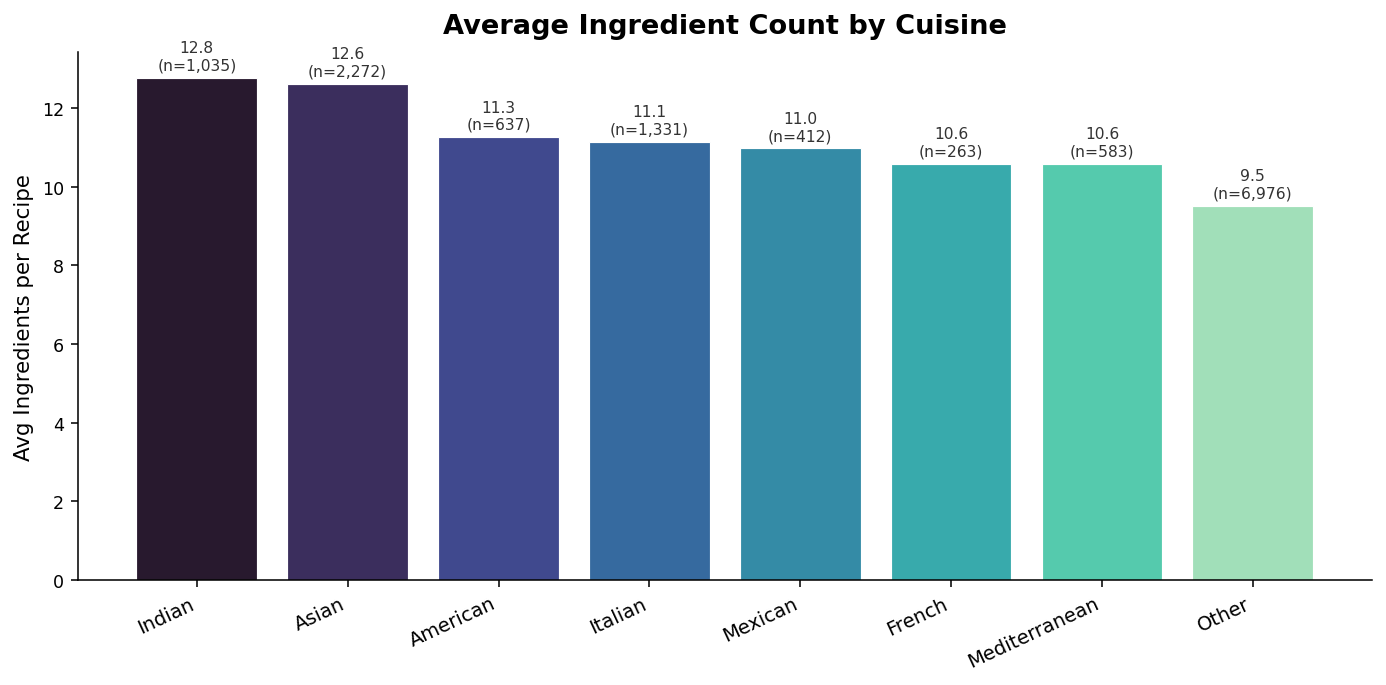

In [16]:
cuisine_stats = (df[df['cuisine'].isin(order)]
                 .groupby('cuisine')['n_ingredients']
                 .agg(['mean', 'median', 'count'])
                 .sort_values('mean', ascending=False))

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(cuisine_stats))
ax.bar(x, cuisine_stats['mean'], color=sns.color_palette('mako', len(cuisine_stats)),
       edgecolor='white', linewidth=0.6)
ax.set_xticks(list(x))
ax.set_xticklabels(cuisine_stats.index, rotation=25, ha='right', fontsize=10)
ax.set_ylabel('Avg Ingredients per Recipe')
ax.set_title('Average Ingredient Count by Cuisine', weight='bold', fontsize=14, pad=10)
for i, (mean_val, count_val) in enumerate(zip(cuisine_stats['mean'], cuisine_stats['count'])):
    ax.text(i, mean_val + 0.2, f'{mean_val:.1f}\n(n={count_val:,})', ha='center', fontsize=8, color='#333')
sns.despine()
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'cuisine_avg_ingredients.png'), bbox_inches='tight')
plt.show()


### 6b -- Recipe Rating vs. Complexity

We examine whether higher-rated recipes (richer in technique and ingredients) tend to be more complex.


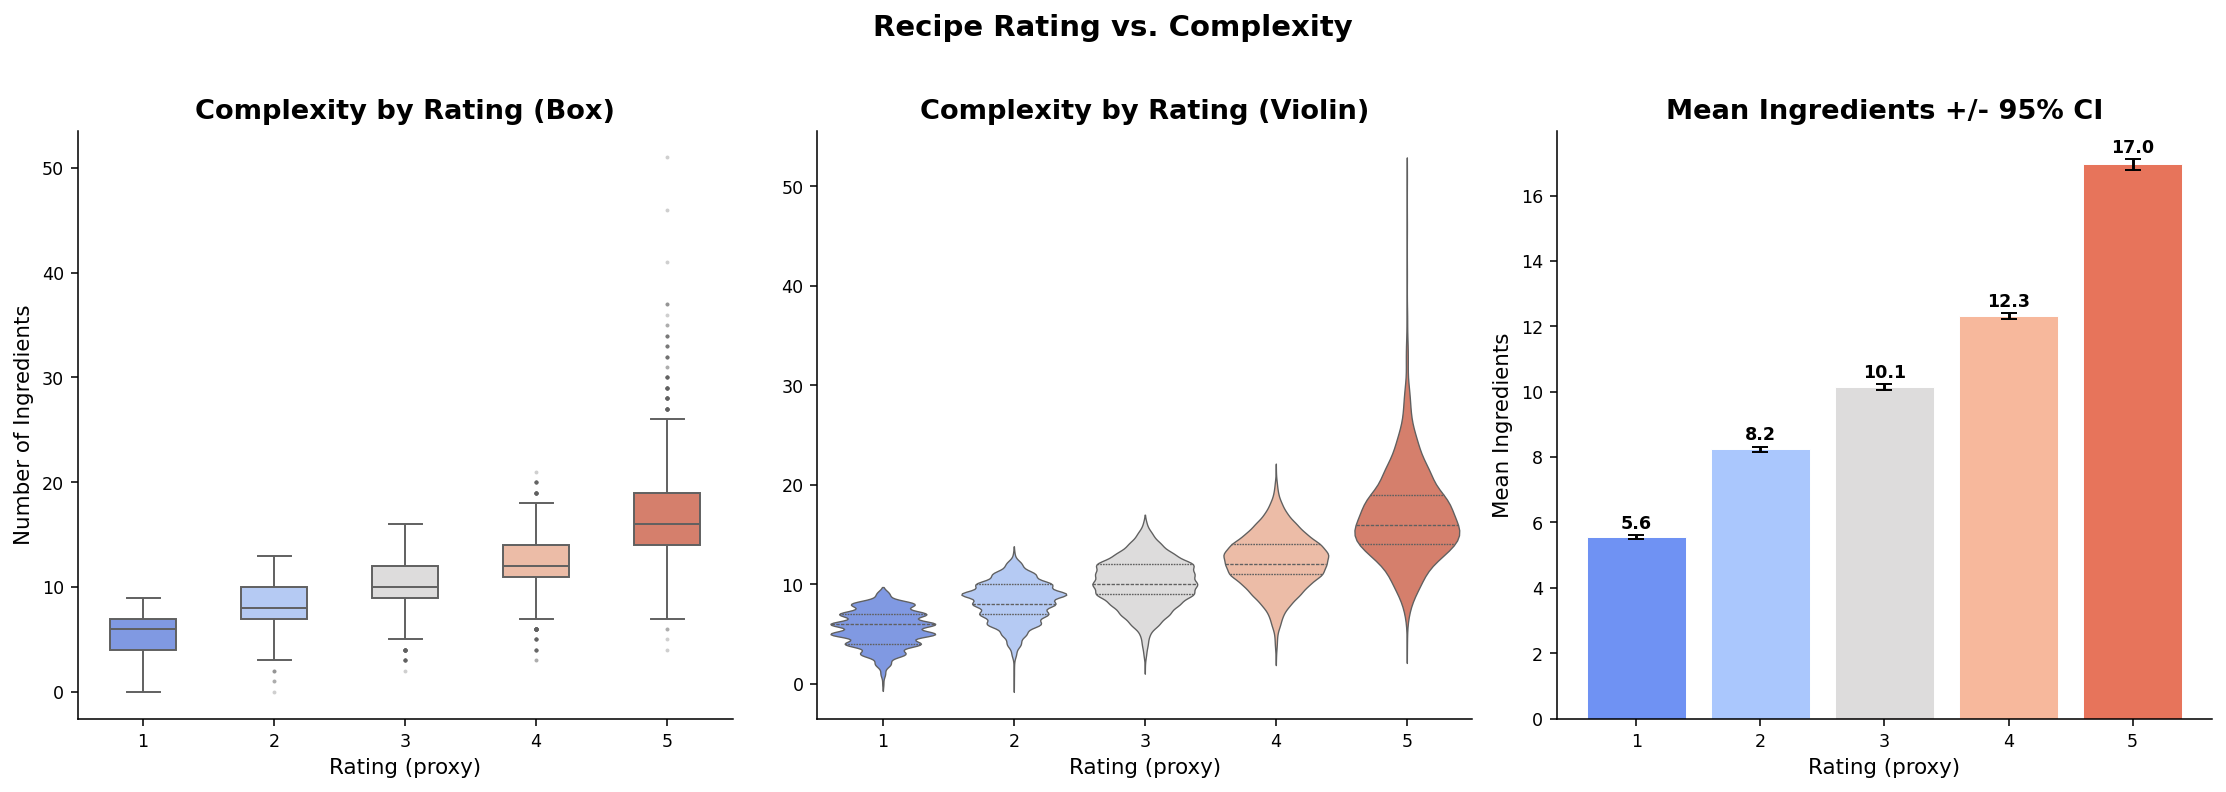

Pearson correlation (rating proxy vs. n_ingredients): 0.788


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))

# Panel 1: Box plot
sns.boxplot(data=df, x='rating', y='n_ingredients', palette='coolwarm',
            width=0.5, flierprops=dict(marker='.', markersize=2, alpha=0.3), ax=axes[0])
axes[0].set_title('Complexity by Rating (Box)', weight='bold')
axes[0].set_xlabel('Rating (proxy)')
axes[0].set_ylabel('Number of Ingredients')
sns.despine(ax=axes[0])

# Panel 2: Violin plot
sns.violinplot(data=df, x='rating', y='n_ingredients', palette='coolwarm',
               inner='quart', linewidth=0.7, ax=axes[1])
axes[1].set_title('Complexity by Rating (Violin)', weight='bold')
axes[1].set_xlabel('Rating (proxy)')
axes[1].set_ylabel('')
sns.despine(ax=axes[1])

# Panel 3: Mean + CI
rating_means = df.groupby('rating')['n_ingredients'].agg(['mean', 'std', 'count'])
rating_means['se'] = rating_means['std'] / np.sqrt(rating_means['count'])
ax = axes[2]
ax.bar(rating_means.index, rating_means['mean'],
       yerr=1.96*rating_means['se'], capsize=4,
       color=sns.color_palette('coolwarm', 5), edgecolor='white', linewidth=0.5)
ax.set_title('Mean Ingredients +/- 95% CI', weight='bold')
ax.set_xlabel('Rating (proxy)')
ax.set_ylabel('Mean Ingredients')
for r_val, row in rating_means.iterrows():
    ax.text(r_val, row['mean'] + 1.96*row['se'] + 0.2, f'{row["mean"]:.1f}',
            ha='center', fontsize=9, weight='bold')
sns.despine(ax=ax)

plt.suptitle('Recipe Rating vs. Complexity', fontsize=15, weight='bold', y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'rating_vs_complexity.png'), bbox_inches='tight')
plt.show()

corr = df[['rating', 'n_ingredients']].corr().iloc[0,1]
print(f'Pearson correlation (rating proxy vs. n_ingredients): {corr:.3f}')


---
## Summary of Findings

| Analysis | Key Finding |
|----------|-------------|
| **Dataset Size** | ~13.5K recipes from Epicurious & Spoonacular |
| **Missing Values** | Minimal nulls; small fraction of unparseable ingredient lists |
| **Top Ingredients** | Butter, olive oil, garlic, sugar, eggs dominate across cuisines |
| **Co-occurrence** | Butter + sugar, garlic + olive oil are the strongest pairs |
| **Complexity** | Most recipes use 8-15 ingredients; heavy right tail |
| **Cuisine vs. Ingredients** | Italian & Mediterranean recipes are most ingredient-dense |
| **Rating vs. Complexity** | Strong positive relationship -- richer recipes score higher on the proxy |

All plots saved to `output_plots/` as PNGs.


In [18]:
print('Saved plots:')
for f in sorted(os.listdir(OUT_DIR)):
    if f.endswith('.png'):
        print(f'  {OUT_DIR}/{f}')
print(f'\nTotal PNGs saved: {len([f for f in os.listdir(OUT_DIR) if f.endswith(".png")])}')


Saved plots:
  /content/drive/Shareddrives/Computer Vision Final Project/EDA/output_plots/complexity_distribution.png
  /content/drive/Shareddrives/Computer Vision Final Project/EDA/output_plots/cuisine_avg_ingredients.png
  /content/drive/Shareddrives/Computer Vision Final Project/EDA/output_plots/cuisine_vs_ingredient_lift.png
  /content/drive/Shareddrives/Computer Vision Final Project/EDA/output_plots/ingredient_cooccurrence_heatmap.png
  /content/drive/Shareddrives/Computer Vision Final Project/EDA/output_plots/missing_values.png
  /content/drive/Shareddrives/Computer Vision Final Project/EDA/output_plots/rating_vs_complexity.png
  /content/drive/Shareddrives/Computer Vision Final Project/EDA/output_plots/top_ingredients_bar.png

Total PNGs saved: 7


In [19]:
# --- Save cleaned dataset with new preprocessing columns ---
save_path = os.path.join(DATA_DIR, 'recipes_cleaned.csv')
df.to_csv(save_path, index=False)
print('Saved cleaned dataset to:', save_path)
print('Columns:', list(df.columns))
print('Rows:', len(df))

Saved cleaned dataset to: /content/drive/Shareddrives/Computer Vision Final Project/Data/recipe_dataset/data/recipes_cleaned.csv
Columns: ['dish_id', 'dish_name', 'recipe', 'photo_path', 'source', 'instructions', 'ingredient_portions', 'ingredients', 'n_ingredients', 'cuisine', 'rating']
Rows: 13509
